In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

def iqr_bounds(series):
    clean = series.dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lower, upper, int(((clean < lower) | (clean > upper)).sum())

# 분석 데이터 전처리

## 데이터 감사표 만들기

In [19]:
raw = pd.read_csv("dataFile/B_스마트팜_토마토품질_dirty.csv")
raw.head()

,batch_id,greenhouse_zone,shift,irrigation_method,worker_experience_years,temperature_c,humidity_pct,soil_moisture_pct,nutrient_ec,fruit_weight_g,sugar_brix,quality_issue
0,B0001,A동,주간,분무,5.0,28.0,71.6,66.0,2.08,148.0,7.72,0
1,B0002,D동,주간,점적,1.0,25.9,58.6,72.2,1.53,170.9,7.12,0
2,B0003,B동,주간,수경,7.0,24.9,64.4,NaN,2.19,199.0,8.07,0
3,B0004,D동,주간,점적,14.0,22.3,70.5,70.2,2.31,168.2,7.31,0
4,B0005,B동,주간,점적,2.0,25.0,70.2,78.0,2.03,194.3,6.92,0


In [20]:
raw.head()
raw.shape   # (602, 12)
raw.info()
raw.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   batch_id                 602 non-null    str    
 1   greenhouse_zone          602 non-null    str    
 2   shift                    602 non-null    str    
 3   irrigation_method        583 non-null    str    
 4   worker_experience_years  579 non-null    float64
 5   temperature_c            602 non-null    float64
 6   humidity_pct             584 non-null    float64
 7   soil_moisture_pct        576 non-null    float64
 8   nutrient_ec              586 non-null    float64
 9   fruit_weight_g           602 non-null    float64
 10  sugar_brix               602 non-null    float64
 11  quality_issue            602 non-null    int64  
dtypes: float64(7), int64(1), str(4)
memory usage: 56.6 KB


,batch_id,greenhouse_zone,shift,irrigation_method,worker_experience_years,temperature_c,humidity_pct,soil_moisture_pct,nutrient_ec,fruit_weight_g,sugar_brix,quality_issue
count,602,602,602,583,579.000000,602.000000,584.000000,576.000000,586.000000,602.000000,602.000000,602.000000
unique,594,4,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,B0026,B동,주간,점적,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,191,355,277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,6.868739,23.993854,69.885445,64.691319,2.179147,179.146512,7.172010,0.079734
std,NaN,NaN,NaN,NaN,4.110924,3.202065,7.644008,10.643443,0.563296,33.984796,0.567495,0.271107
min,NaN,NaN,NaN,NaN,0.000000,16.000000,46.100000,9.100000,1.100000,116.000000,5.260000,0.000000
25%,NaN,NaN,NaN,NaN,4.000000,22.125000,64.700000,57.800000,1.882500,164.350000,6.800000,0.000000
50%,NaN,NaN,NaN,NaN,7.000000,23.800000,70.100000,63.800000,2.150000,176.400000,7.160000,0.000000
75%,NaN,NaN,NaN,NaN,10.000000,25.500000,75.100000,70.925000,2.410000,189.300000,7.537500,0.000000


In [21]:
data_audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "unique_count": raw.nunique(dropna=True),
    "missing_count": raw.isna().sum(),
    "missing_ratio": raw.isna().mean(),
})
data_audit

,dtype,unique_count,missing_count,missing_ratio
batch_id,str,594,0,0.000000
greenhouse_zone,str,4,0,0.000000
shift,str,2,0,0.000000
irrigation_method,str,3,19,0.031561
worker_experience_years,float64,21,23,0.038206
temperature_c,float64,115,0,0.000000
humidity_pct,float64,258,18,0.029900
soil_moisture_pct,float64,288,26,0.043189
nutrient_ec,float64,163,16,0.026578
fruit_weight_g,float64,407,0,0.000000


In [22]:
raw.select_dtypes(include="number").columns.difference(["quality_issue"])

Index(['fruit_weight_g', 'humidity_pct', 'nutrient_ec', 'soil_moisture_pct',
       'sugar_brix', 'temperature_c', 'worker_experience_years'],
      dtype='str')

In [23]:
print("명목형: greenhouse_zone, irrigation_method")
print("이진형: shift, quality_issue")

명목형: greenhouse_zone, irrigation_method
이진형: shift, quality_issue


In [24]:
raw.duplicated().sum()          # 6
raw["batch_id"].duplicated().sum()  # 8

np.int64(8)

## 결측치 처리 비교

In [25]:
farm_pre = raw.copy()
dedup = farm_pre.drop_duplicates().copy()
dedup.shape[0]   # 602 - 6 = 596

596

In [26]:
# batch_id는 같은데 값이 다른 행은 그룹화해서 통합 (quality_issue는 평균 대신 첫 값 사용)
num_for_mean = dedup.select_dtypes(include="number").columns.difference(["quality_issue"])
aggregate = {col: "first" for col in dedup.columns if col not in {"batch_id", *num_for_mean}}
aggregate.update({col: "mean" for col in num_for_mean})

In [27]:
df = dedup.groupby("batch_id", as_index=False, sort=False).agg(aggregate)
df

,batch_id,greenhouse_zone,shift,irrigation_method,quality_issue,fruit_weight_g,humidity_pct,nutrient_ec,soil_moisture_pct,sugar_brix,temperature_c,worker_experience_years
0,B0001,A동,주간,분무,0,148.0,71.6,2.08,66.0,7.72,28.0,5.0
1,B0002,D동,주간,점적,0,170.9,58.6,1.53,72.2,7.12,25.9,1.0
2,B0003,B동,주간,수경,0,199.0,64.4,2.19,NaN,8.07,24.9,7.0
3,B0004,D동,주간,점적,0,168.2,70.5,2.31,70.2,7.31,22.3,14.0
4,B0005,B동,주간,점적,0,194.3,70.2,2.03,78.0,6.92,25.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
589,B0590,B동,야간,점적,0,141.6,79.0,2.15,55.6,7.46,19.2,9.0
590,B0591,C동,주간,분무,0,170.2,72.1,2.13,61.0,6.26,23.5,11.0
591,B0592,B동,주간,점적,0,181.1,71.3,1.87,55.1,7.01,22.3,8.0
592,B0593,C동,주간,점적,0,175.9,67.6,NaN,56.4,7.49,23.1,7.0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   batch_id                 594 non-null    str    
 1   greenhouse_zone          594 non-null    str    
 2   shift                    594 non-null    str    
 3   irrigation_method        575 non-null    str    
 4   quality_issue            594 non-null    int64  
 5   fruit_weight_g           594 non-null    float64
 6   humidity_pct             576 non-null    float64
 7   nutrient_ec              578 non-null    float64
 8   soil_moisture_pct        568 non-null    float64
 9   sugar_brix               594 non-null    float64
 10  temperature_c            594 non-null    float64
 11  worker_experience_years  571 non-null    float64
dtypes: float64(7), int64(1), str(4)
memory usage: 55.8 KB


In [29]:
df["irrigation_method"] = df["irrigation_method"].fillna("미상")
df["worker_experience_years"] = df["worker_experience_years"].fillna(df["worker_experience_years"].median())
df.shape

(594, 12)

In [30]:
# 전체 중앙값으로 채운 경우와 구역별 중앙값으로 채운 경우를 비교
sensor_cols = ["humidity_pct", "soil_moisture_pct", "nutrient_ec"]
df.groupby("greenhouse_zone")[sensor_cols].median()

,humidity_pct,soil_moisture_pct,nutrient_ec
greenhouse_zone,,,
A동,68.40,63.4,2.145
B동,70.20,64.9,2.120
C동,71.20,62.6,2.210
D동,71.15,64.2,2.145


In [31]:
# 구역 간 차이를 보존하기 위해 구역별 중앙값으로 대체
for col in sensor_cols:
    df[col] = df[col].fillna(df.groupby("greenhouse_zone")[col].transform("median"))

df.isnull().sum()

batch_id                   0
greenhouse_zone            0
shift                      0
irrigation_method          0
quality_issue              0
fruit_weight_g             0
humidity_pct               0
nutrient_ec                0
soil_moisture_pct          0
sugar_brix                 0
temperature_c              0
worker_experience_years    0
dtype: int64

## 센서 이상치와 실제 희귀값 구분

<Axes: >

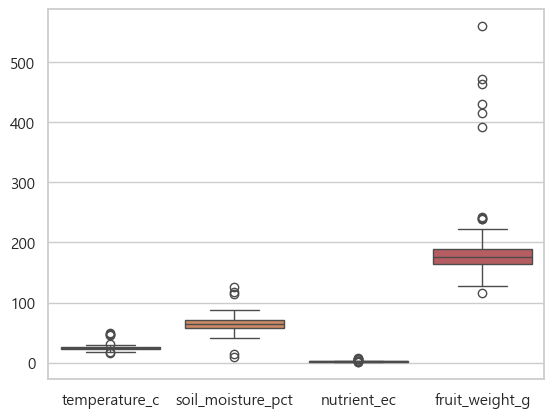

In [32]:
outlier_cols = ["temperature_c", "soil_moisture_pct", "nutrient_ec", "fruit_weight_g"]

sns.boxplot(data=df[outlier_cols])

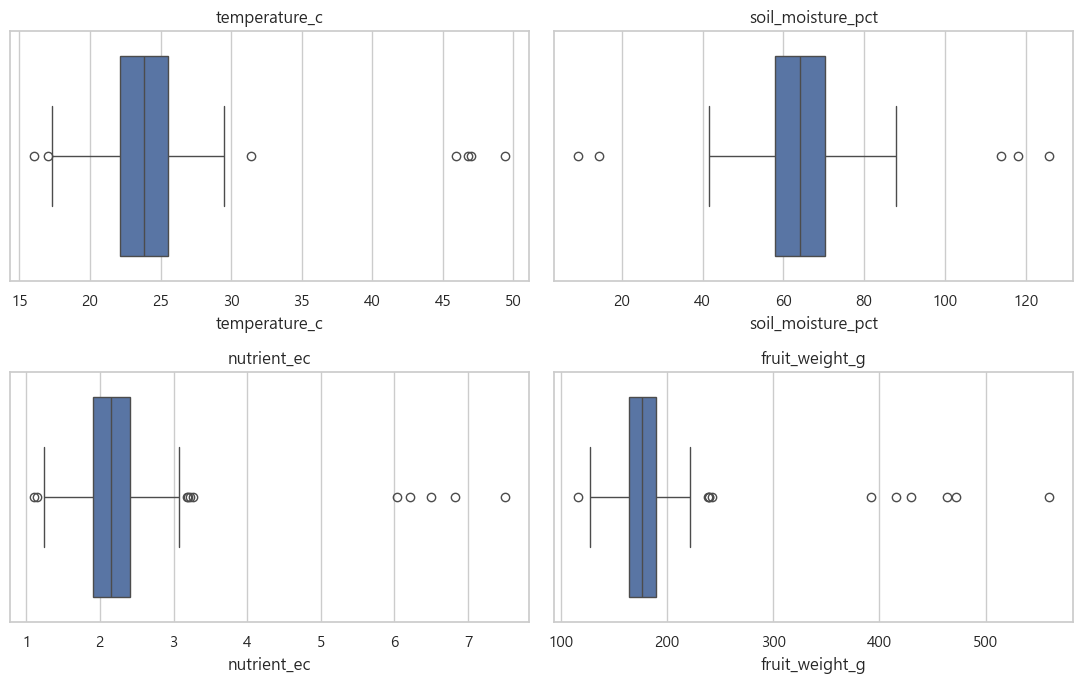

In [33]:
# 컬럼마다 단위가 달라서 한 그래프로는 비교가 어려움 -> 컬럼별로 따로 확인
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, ax in zip(outlier_cols, axes.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()

In [34]:
bounds = {}
for col in outlier_cols:
    lower, upper, count = iqr_bounds(df[col])
    bounds[col] = {"lower": lower, "upper": upper, "outlier_count": count}

pd.DataFrame(bounds).T

,lower,upper,outlier_count
temperature_c,17.0625,30.5625,7.0
soil_moisture_pct,39.3625,89.0625,5.0
nutrient_ec,1.1600,3.1600,11.0
fruit_weight_g,126.5375,227.2375,11.0


In [35]:
# 토양수분은 0~100% 밖이면 명백한 오류 -> capping
df["sensor_range_error"] = (~df["soil_moisture_pct"].between(0, 100)).astype("int8")
df["soil_moisture_pct"] = df["soil_moisture_pct"].clip(0, 100)

In [36]:
# 나머지는 실제 희귀값일 수 있으므로 원본을 유지하고 플래그만 생성
for source, flag in [("temperature_c", "temperature_outlier"), ("nutrient_ec", "ec_outlier"), ("fruit_weight_g", "weight_outlier")]:
    lower, upper, _ = iqr_bounds(df[source])
    df[flag] = ((df[source] < lower) | (df[source] > upper)).astype("int8")

In [37]:
df[["sensor_range_error", "temperature_outlier", "ec_outlier", "weight_outlier"]].sum()

sensor_range_error      3
temperature_outlier     7
ec_outlier             11
weight_outlier         11
dtype: int64

## 분석용 변수 변환

In [38]:
df["moisture_gap"] = (df["soil_moisture_pct"] - 65).abs()
df["moisture_gap"].describe()

count    594.000000
mean       7.684175
std        6.435532
min        0.000000
25%        2.825000
50%        6.450000
75%       11.150000
max       55.900000
Name: moisture_gap, dtype: float64

In [39]:
df["temp_humidity_index"] = df["temperature_c"] * df["humidity_pct"] / 100
df["weight_sugar_score"] = df["fruit_weight_g"] * df["sugar_brix"]
df[["temp_humidity_index", "weight_sugar_score"]].describe()

,temp_humidity_index,weight_sugar_score
count,594.000000,594.000000
mean,16.770346,1285.543807
std,2.899431,272.706250
min,10.732600,794.880000
25%,15.030075,1149.297000
50%,16.646000,1255.509000
75%,18.292350,1394.151500
max,40.063400,4064.148000


In [40]:
model_df = df.copy()
model_df["shift"] = model_df["shift"].map({"야간": 0, "주간": 1})
model_df["shift"].value_counts()

shift
1    349
0    245
Name: count, dtype: int64

In [41]:
model_df = pd.get_dummies(model_df, columns=["greenhouse_zone", "irrigation_method"], dtype="int8")
model_df.shape

(594, 25)

In [42]:
scale_cols = ["worker_experience_years", "temperature_c", "humidity_pct", "soil_moisture_pct",
              "nutrient_ec", "fruit_weight_g", "sugar_brix", "moisture_gap",
              "temp_humidity_index", "weight_sugar_score"]
model_df[scale_cols] = StandardScaler().fit_transform(model_df[scale_cols])
model_df[scale_cols].describe().loc[["mean", "std"]]

,worker_experience_years,temperature_c,humidity_pct,soil_moisture_pct,nutrient_ec,fruit_weight_g,sugar_brix,moisture_gap,temp_humidity_index,weight_sugar_score
mean,9.569599e-17,-3.125072e-16,8.919165e-16,1.226105e-16,6.579099e-16,-5.382900e-17,1.271710e-15,5.681949e-17,5.046468e-16,-2.033540e-16
std,1.000843e+00,1.000843e+00,1.000843e+00,1.000843e+00,1.000843e+00,1.000843e+00,1.000843e+00,1.000843e+00,1.000843e+00,1.000843e+00


In [43]:
model_df.to_csv("B_스마트팜_cleaned.csv", index=False)
print("저장 완료:", model_df.shape)

저장 완료: (594, 25)


# 탐색적 데이터 분석

## 품질 이상 표본과 분포 확인

In [44]:
quality = df["quality_issue"].value_counts().to_frame("count")
quality["ratio"] = df["quality_issue"].value_counts(normalize=True)
quality

,count,ratio
quality_issue,,
0,547,0.920875
1,47,0.079125


Text(0.5, 1.0, '품질 이상 여부별 당도 분포')

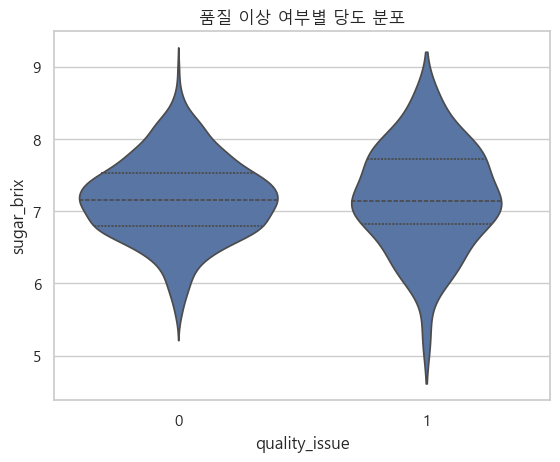

In [45]:
sns.violinplot(data=df, x="quality_issue", y="sugar_brix", inner="quart")
plt.title("품질 이상 여부별 당도 분포")

## 관수 방식과 구역별 비교

In [47]:
pd.crosstab(df["irrigation_method"], df["quality_issue"], normalize="index")

quality_issue,0,1
irrigation_method,,
미상,0.894737,0.105263
분무,0.942623,0.057377
수경,0.911602,0.088398
점적,0.919118,0.080882


In [48]:
zone_quality = df.groupby("greenhouse_zone").agg(
    n=("batch_id", "size"), weight_mean=("fruit_weight_g", "mean"),
    weight_median=("fruit_weight_g", "median"), sugar_mean=("sugar_brix", "mean"),
    sugar_median=("sugar_brix", "median"),
)
zone_quality

,n,weight_mean,weight_median,sugar_mean,sugar_median
greenhouse_zone,,,,,
A동,152,177.637171,173.6,7.200855,7.210
B동,188,184.846809,180.5,7.112686,7.115
C동,151,178.559603,177.6,7.183576,7.180
D동,103,172.035922,170.5,7.215146,7.150


In [49]:
zone_shift = df.groupby(["greenhouse_zone", "shift"])["quality_issue"].agg(n="size", issue_count="sum", issue_ratio="mean")
zone_shift

n  issue_count  issue_ratio
greenhouse_zone shift                               
A동              야간      65            8     0.123077
                주간      87            4     0.045977
B동              야간      80            8     0.100000
                주간     108            6     0.055556
C동              야간      56            5     0.089286
                주간      95            8     0.084211
D동              야간      44            4     0.090909
                주간      59            4     0.067797

## 환경 변수 관계 분석

Text(0.5, 1.0, '환경·품질 변수 상관관계')

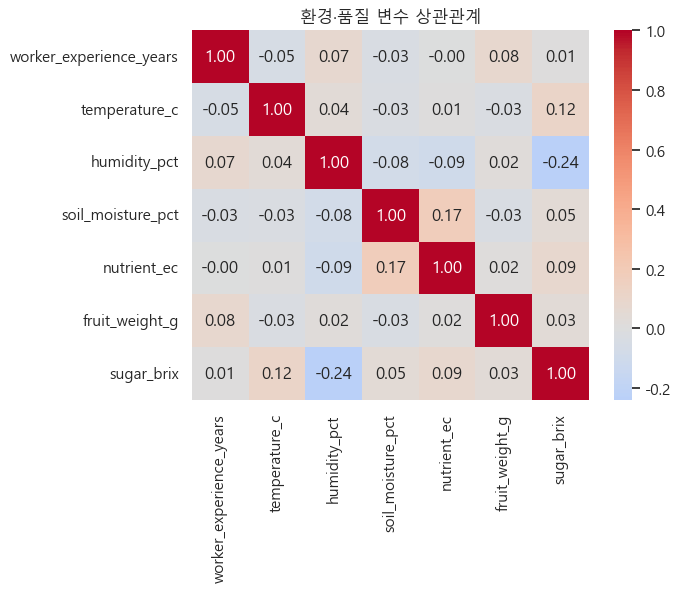

In [50]:
corr_cols = ["worker_experience_years", "temperature_c", "humidity_pct", "soil_moisture_pct", "nutrient_ec", "fruit_weight_g", "sugar_brix"]
sns.heatmap(df[corr_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("환경·품질 변수 상관관계")

Text(0.5, 1.0, '토양수분 vs 당도')

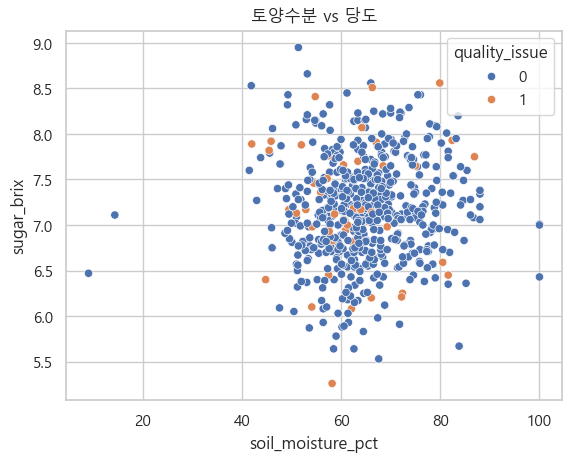

In [51]:
sns.scatterplot(data=df, x="soil_moisture_pct", y="sugar_brix", hue="quality_issue")
plt.title("토양수분 vs 당도")

In [52]:
df["temperature_band"] = pd.cut(
    df["temperature_c"], bins=[-np.inf, 20, 24, 28, np.inf],
    labels=["20 미만", "20~24", "24~28", "28 이상"], right=False
)
df["temperature_band"].value_counts()

temperature_band
20~24    273
24~28    256
28 이상     33
20 미만     32
Name: count, dtype: int64

In [54]:
temp_quality = df.groupby("temperature_band", observed=False)["quality_issue"].agg(n="size", issue_count="sum", issue_ratio="mean")
temp_quality

,n,issue_count,issue_ratio
temperature_band,,,
20 미만,32,5,0.156250
20~24,273,25,0.091575
24~28,256,16,0.062500
28 이상,33,1,0.030303


## 품질관리 보고 요약

In [55]:
top_irrigation = (
    df[df["irrigation_method"].ne("미상")]
    .groupby("irrigation_method")["quality_issue"]
    .agg(n="size", ratio="mean")
    .sort_values("ratio", ascending=False)
)
top_irrigation

,n,ratio
irrigation_method,,
수경,181,0.088398
점적,272,0.080882
분무,122,0.057377


In [56]:
top_temp = temp_quality.sort_values("issue_ratio", ascending=False)
top_temp

,n,issue_count,issue_ratio
temperature_band,,,
20 미만,32,5,0.156250
20~24,273,25,0.091575
24~28,256,16,0.062500
28 이상,33,1,0.030303


In [57]:
best_irrigation = top_irrigation.iloc[0]
best_temp = top_temp.iloc[0]
print(f"1) 이상은 최고 관수 방식에서 {best_irrigation['ratio']:.1%}(n={best_irrigation['n']:.0f}), "
      f"최고 온도 구간에서 {best_temp['issue_ratio']:.1%}(n={best_temp['n']:.0f}) 관찰되었다.")
print("2) 이는 관찰 자료의 연관이며 교란요인이 있어 원인을 확정할 수 없다.")
print(f"3) 수분 범위 오류 {df['sensor_range_error'].sum()}건은 결과를 왜곡할 수 있어 보정 전후 비교가 필요하다.")

1) 이상은 최고 관수 방식에서 8.8%(n=181), 최고 온도 구간에서 15.6%(n=32) 관찰되었다.
2) 이는 관찰 자료의 연관이며 교란요인이 있어 원인을 확정할 수 없다.
3) 수분 범위 오류 3건은 결과를 왜곡할 수 있어 보정 전후 비교가 필요하다.
